# Introduction to Feature Engineering

## Warm-up: Solve the tasks

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('penguins_simple.csv', sep=';')
df.head(3)

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie,39.1,18.7,181.0,3750.0,MALE
1,Adelie,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,40.3,18.0,195.0,3250.0,FEMALE


Today we do not want to predict the species. We do not want to create a model at all. But we want to modify/engineer some columns for later use.

In [3]:
# combine species and sex into a new column
df['sexspecies'] = df['Species'].str[:3] + '_' + df['Sex'].str[:1]

In [4]:
df.head(3)

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,sexspecies
0,Adelie,39.1,18.7,181.0,3750.0,MALE,Ade_M
1,Adelie,39.5,17.4,186.0,3800.0,FEMALE,Ade_F
2,Adelie,40.3,18.0,195.0,3250.0,FEMALE,Ade_F


<AxesSubplot:xlabel='Body Mass (g)', ylabel='Culmen Length (mm)'>

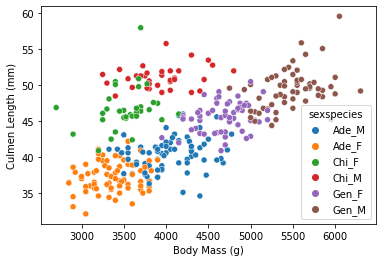

In [5]:
# create a scatterplot with culmen length over kilos, hue = sexspecies
sns.scatterplot(data=df, y='Culmen Length (mm)', x='Body Mass (g)', hue='sexspecies')

## Why Feature Engineering?

Or: On what basis of information should a model be built on?

* LogReg input are multiple columns (features)
* LogReg assigns one coefficient per feature
* &rightarrow; number and kind of features determines power of the model
* more features &rightarrow; more information &rightarrow; closer predictions
* features should contain **useful information**
* features should not be redundant
* all features have to be floating-point numbers  

Feature Engineering is processing columns (= features) that can improve the model.

### Estimated time spent with data organizing

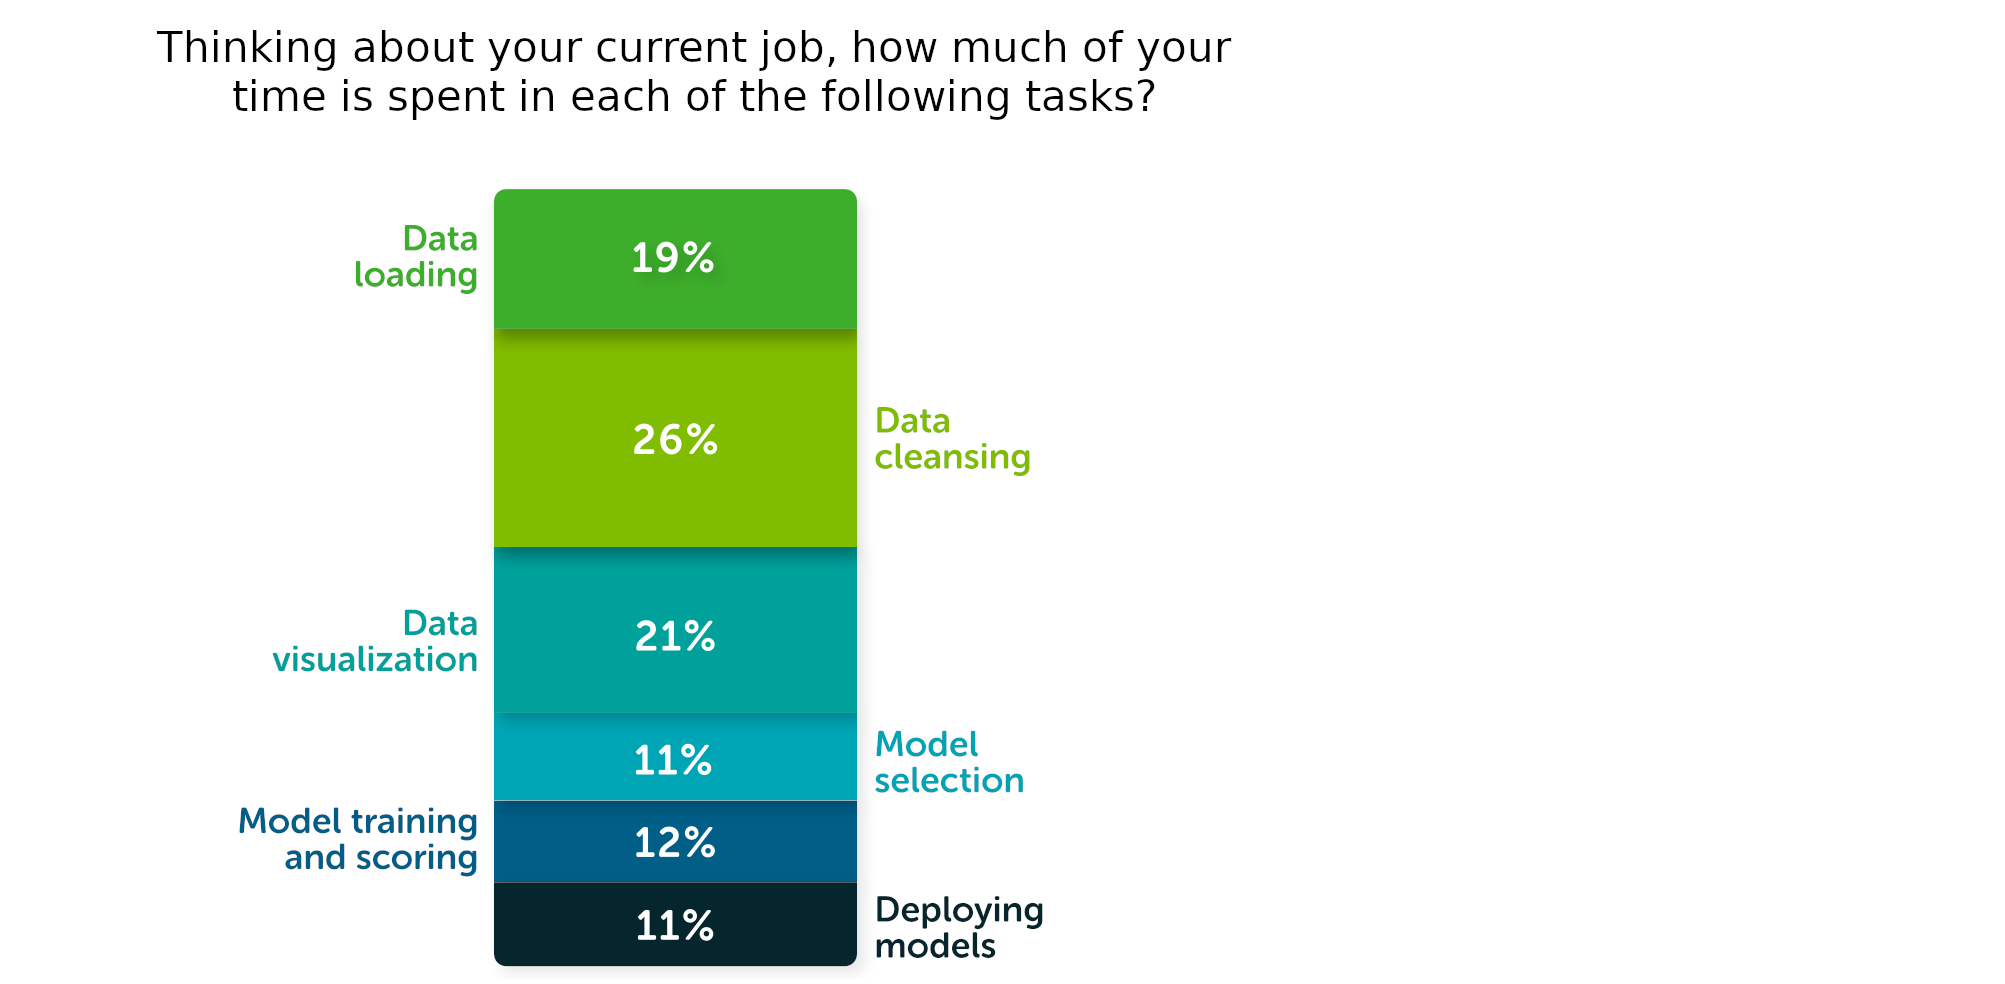

Figure taken from [here](https://www.anaconda.com/state-of-data-science-2020?utm_medium=press&utm_source=anaconda&utm_campaign=sods-2020&utm_content=report).  
Different result can be found [here](https://www.forbes.com/sites/gilpress/2016/03/23/data-preparation-most-time-consuming-least-enjoyable-data-science-task-survey-says/).

## 0. Explore the data

&rightarrow; only roughly today. Look at the last week's tools for more details.

In [6]:
df.head(12)

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,sexspecies
0,Adelie,39.1,18.7,181.0,3750.0,MALE,Ade_M
1,Adelie,39.5,17.4,186.0,3800.0,FEMALE,Ade_F
2,Adelie,40.3,18.0,195.0,3250.0,FEMALE,Ade_F
3,Adelie,36.7,19.3,193.0,3450.0,FEMALE,Ade_F
4,Adelie,39.3,20.6,190.0,3650.0,MALE,Ade_M
5,Adelie,38.9,17.8,181.0,3625.0,FEMALE,Ade_F
6,Adelie,39.2,19.6,195.0,4675.0,MALE,Ade_M
7,Adelie,41.1,17.6,182.0,3200.0,FEMALE,Ade_F
8,Adelie,38.6,21.2,191.0,3800.0,MALE,Ade_M
9,Adelie,34.6,21.1,198.0,4400.0,MALE,Ade_M


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              333 non-null    object 
 1   Culmen Length (mm)   333 non-null    float64
 2   Culmen Depth (mm)    333 non-null    float64
 3   Flipper Length (mm)  333 non-null    float64
 4   Body Mass (g)        333 non-null    float64
 5   Sex                  333 non-null    object 
 6   sexspecies           333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.3+ KB


For conversion you may like to use `.astype(str)`.

You can check pandas data types here: https://pbpython.com/pandas_dtypes.html

## 1. Imputation

replace empty values by non-empty values

### with a certain (pre-calculated) value

In [8]:
# introduce missing values (to provide an example)
import numpy as np

df.iloc[3:10,3] = np.nan

In [9]:
df.head(12)

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,sexspecies
0,Adelie,39.1,18.7,181.0,3750.0,MALE,Ade_M
1,Adelie,39.5,17.4,186.0,3800.0,FEMALE,Ade_F
2,Adelie,40.3,18.0,195.0,3250.0,FEMALE,Ade_F
3,Adelie,36.7,19.3,NaN,3450.0,FEMALE,Ade_F
4,Adelie,39.3,20.6,NaN,3650.0,MALE,Ade_M
5,Adelie,38.9,17.8,NaN,3625.0,FEMALE,Ade_F
6,Adelie,39.2,19.6,NaN,4675.0,MALE,Ade_M
7,Adelie,41.1,17.6,NaN,3200.0,FEMALE,Ade_F
8,Adelie,38.6,21.2,NaN,3800.0,MALE,Ade_M
9,Adelie,34.6,21.1,NaN,4400.0,MALE,Ade_M


<AxesSubplot:>

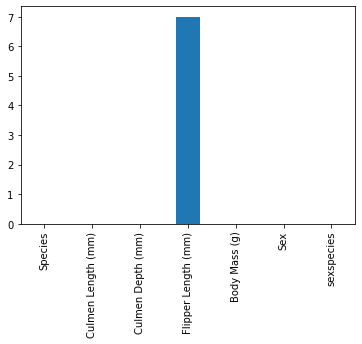

In [10]:
df.isna().sum().plot.bar() # checks for missing values

In [12]:
df[df['Flipper Length (mm)'].isna()]  # all rows with "True"

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,sexspecies
3,Adelie,36.7,19.3,NaN,3450.0,FEMALE,Ade_F
4,Adelie,39.3,20.6,NaN,3650.0,MALE,Ade_M
5,Adelie,38.9,17.8,NaN,3625.0,FEMALE,Ade_F
6,Adelie,39.2,19.6,NaN,4675.0,MALE,Ade_M
7,Adelie,41.1,17.6,NaN,3200.0,FEMALE,Ade_F
8,Adelie,38.6,21.2,NaN,3800.0,MALE,Ade_M
9,Adelie,34.6,21.1,NaN,4400.0,MALE,Ade_M


In [13]:
df['flipper_new'] = df['Flipper Length (mm)'].fillna(0.0) # zero, mean, random, median, backfill/forwardfill/interpolation (time series) 

df[['Flipper Length (mm)', 'flipper_new']].head(5)

,Flipper Length (mm),flipper_new
0,181.0,181.0
1,186.0,186.0
2,195.0,195.0
3,NaN,0.0
4,NaN,0.0


In [14]:
mean = df['Flipper Length (mm)'].mean()   # often also median
mean

201.20245398773005

In [15]:
df['flipper_new'] = df['Flipper Length (mm)'].fillna(mean)

df[['Flipper Length (mm)', 'flipper_new']].head(5)

,Flipper Length (mm),flipper_new
0,181.0,181.000000
1,186.0,186.000000
2,195.0,195.000000
3,NaN,201.202454
4,NaN,201.202454


In [16]:
df.groupby('sexspecies')['Flipper Length (mm)'].mean()

sexspecies
Ade_F    187.900000
Ade_M    192.347826
Chi_F    191.735294
Chi_M    199.911765
Gen_F    212.706897
Gen_M    221.540984
Name: Flipper Length (mm), dtype: float64

In [17]:
df.groupby('sexspecies')['Flipper Length (mm)'].transform('mean')

0      192.347826
1      187.900000
2      187.900000
3      187.900000
4      192.347826
          ...    
328    212.706897
329    212.706897
330    221.540984
331    212.706897
332    221.540984
Name: Flipper Length (mm), Length: 333, dtype: float64

In [18]:
# very powerful imputation strategy!!
groupmeans = df.groupby('sexspecies')['Flipper Length (mm)'].transform('mean') # number of rows stays the same


df['flipper_new'] = df['Flipper Length (mm)'].fillna(groupmeans)

# in the Titanic data, do not use the Survived column for imputation

In [20]:
df.head(12)

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,sexspecies,flipper_new
0,Adelie,39.1,18.7,181.0,3750.0,MALE,Ade_M,181.000000
1,Adelie,39.5,17.4,186.0,3800.0,FEMALE,Ade_F,186.000000
2,Adelie,40.3,18.0,195.0,3250.0,FEMALE,Ade_F,195.000000
3,Adelie,36.7,19.3,NaN,3450.0,FEMALE,Ade_F,187.900000
4,Adelie,39.3,20.6,NaN,3650.0,MALE,Ade_M,192.347826
5,Adelie,38.9,17.8,NaN,3625.0,FEMALE,Ade_F,187.900000
6,Adelie,39.2,19.6,NaN,4675.0,MALE,Ade_M,192.347826
7,Adelie,41.1,17.6,NaN,3200.0,FEMALE,Ade_F,187.900000
8,Adelie,38.6,21.2,NaN,3800.0,MALE,Ade_M,192.347826
9,Adelie,34.6,21.1,NaN,4400.0,MALE,Ade_M,192.347826


### Backward/Forward Fill, Interpolation and Dropping the NAs

In [27]:
nan_col = pd.Series([1.0, 2.0, np.nan, np.nan, 4.0, 5.0, np.nan, 7.0])
nan_col

0    1.0
1    2.0
2    NaN
3    NaN
4    4.0
5    5.0
6    NaN
7    7.0
dtype: float64

In [28]:
nan_col.interpolate(method='linear')

0    1.000000
1    2.000000
2    2.666667
3    3.333333
4    4.000000
5    5.000000
6    6.000000
7    7.000000
dtype: float64

In [29]:
nan_col.fillna(method='ffill')

0    1.0
1    2.0
2    2.0
3    2.0
4    4.0
5    5.0
6    5.0
7    7.0
dtype: float64

In [30]:
nan_col.fillna(method='bfill')

0    1.0
1    2.0
2    4.0
3    4.0
4    4.0
5    5.0
6    7.0
7    7.0
dtype: float64

In [ ]:
nan_col.dropna() # <-- easy but not that reasonable because it drops information

### sklearn variant

```python
from sklearn.impute import SimpleImputer
```
Check out [here](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) for an example.

### Diving deeper

- [Different types](https://www.youtube.com/watch?v=YpqUbirqFxQ) of missing values
- [List](https://www.geo.fu-berlin.de/en/v/soga/Geodata-analysis/time-series-analysis/Dealing-with-missing-values/index.html) of imputers for R (several of which also available for python), e.g.
  - sklearn's [KNNImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html) or [IterativeImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html), ...


## 2. One-Hot-Encoding

One hot encoding (= get dummies) means creating new columns, one for each unique value of the column in question. Corresponding (hot) rows get a "1" (one), all other a zero.  

Note:
* Gets around the problem of ordinal relationships between numbers which are not meant to be ordinal.  
 Enumerating categorical variables might introduce a bias in the model.
* For avoiding redundancy: drop one of the columns.

In [31]:
df['sexspecies'].unique()

array(['Ade_M', 'Ade_F', 'Chi_F', 'Chi_M', 'Gen_F', 'Gen_M'], dtype=object)

In [33]:
# categorical column --> numbers
pd.get_dummies(df['sexspecies'], drop_first=True)

,Ade_M,Chi_F,Chi_M,Gen_F,Gen_M
0,1,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,1,0,0,0,0
...,...,...,...,...,...
328,0,0,0,1,0
329,0,0,0,1,0
330,0,0,0,0,1
331,0,0,0,1,0


### sklearn variant

```python
from sklearn.preprocessing import OneHotEncoder
```
Check out [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) for an example.

## 3. Binning

Binning means grouping continuous values into a discrete number of bins.  
It reduces the amount of information (e.g. for handling noisy data): metric &rightarrow; category  

### Provide bin borders manually

In [34]:
bins = pd.cut(df['Body Mass (g)'], bins=[0, 1000, 4000, 10000], labels=['light', 'medium', 'heavy'])
bins

0      medium
1      medium
2      medium
3      medium
4      medium
        ...  
328     heavy
329     heavy
330     heavy
331     heavy
332     heavy
Name: Body Mass (g), Length: 333, dtype: category
Categories (3, object): ['light' < 'medium' < 'heavy']

In [35]:
type(bins)

pandas.core.series.Series

In [36]:
bins.value_counts()

heavy     167
medium    166
light       0
Name: Body Mass (g), dtype: int64

### Same bin size

In [39]:
bins = pd.cut(df['Body Mass (g)'], bins=3, labels=['light', 'medium', 'heavy'], retbins=True)  
bins

(0       light
 1       light
 2       light
 3       light
 4       light
         ...  
 328    medium
 329    medium
 330     heavy
 331     heavy
 332     heavy
 Name: Body Mass (g), Length: 333, dtype: category
 Categories (3, object): ['light' < 'medium' < 'heavy'],
 array([2696.4, 3900. , 5100. , 6300. ]))

In [38]:
bins.value_counts()

light     150
medium    128
heavy      55
Name: Body Mass (g), dtype: int64

### group same number of oberservations in each bin

In [40]:
bins = pd.qcut(df['Body Mass (g)'], q=3)  # q means quantile based binning
bins

0        (3700.0, 4550.0]
1        (3700.0, 4550.0]
2      (2699.999, 3700.0]
3      (2699.999, 3700.0]
4      (2699.999, 3700.0]
              ...        
328      (4550.0, 6300.0]
329      (4550.0, 6300.0]
330      (4550.0, 6300.0]
331      (4550.0, 6300.0]
332      (4550.0, 6300.0]
Name: Body Mass (g), Length: 333, dtype: category
Categories (3, interval[float64, right]): [(2699.999, 3700.0] < (3700.0, 4550.0] < (4550.0, 6300.0]]

In [41]:
bins.value_counts()

(2699.999, 3700.0]    113
(3700.0, 4550.0]      110
(4550.0, 6300.0]      110
Name: Body Mass (g), dtype: int64

You can combine binning with one hot encoding like this

In [42]:
bins = pd.cut(df['Body Mass (g)'], bins=3, labels=['light', 'medium', 'heavy'])
pd.get_dummies(bins, drop_first=True)

,medium,heavy
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
328,1,0
329,1,0
330,0,1
331,0,1


### sklearn variant

```python
from sklearn.preprocessing import KBinsDiscretizer
```
Check out [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.KBinsDiscretizer.html) for an example.

## 4. Scaling

Features being on different scales is usually bad for the model, e.g.  
&emsp; *distance earth to sun:*   0 ... 150,000,000,000 meter  
&emsp; *temperature of earth:*   -89.2 ... 56.7 °C  
 &rightarrow; model would focus more on distance than on temperature

$+$ scaling gives you better results  
$-$ you (the human) may loose the sense of the original number range

### Min-Max Scaler

$$x_{i,scaled} = \frac{x_i - min(x)}{max(x) - min(x)}$$
* smallest value is 0, highest value is 1.0
* Useful for support vector machines.
* Outliers might dominate the range.

<AxesSubplot:>

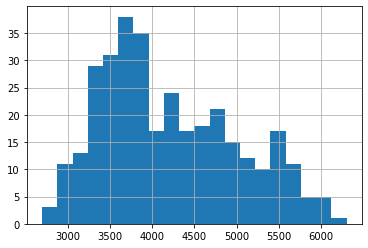

In [43]:
df['Body Mass (g)'].hist(bins=20)

In [44]:
weight_range = df['Body Mass (g)'].max() - df['Body Mass (g)'].min()
weight_range

3600.0

<AxesSubplot:>

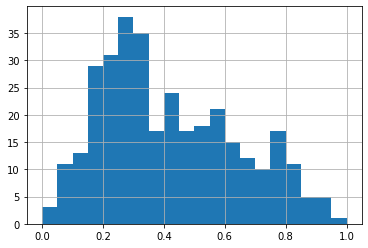

In [45]:
scaled = (df['Body Mass (g)'] - df['Body Mass (g)'].min() ) / weight_range
scaled.hist(bins=20)

###  Standard Scaler

$$x_{i,scaled} = \frac{x_i - mean(x)}{sd(x)}$$
* Centers the data and scales by standard deviation 
* Useful for clustering.
* It is used to prevent a feature whose value is naturally larger from dominating the objective function of your learning algorithm. 
* It follows the standard normal distribution.

In [46]:
scaled = (df['Body Mass (g)'] - df['Body Mass (g)'].mean()) / df['Body Mass (g)'].std()

<AxesSubplot:>

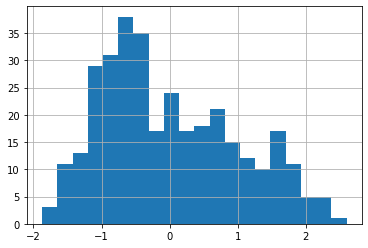

In [47]:
scaled.hist(bins=20)

### Robust Scaler

$$x_{i,scaled} = \frac{x_i - median(x)}{IQR(x)}$$ 

* Takes out the median and scales by the IQR: 
* Similar to StandardScaler **but**
* More robust to outliers, WHY? because IQR is stable against outliers

In [48]:
iqr = df['Body Mass (g)'].quantile(0.75) - df['Body Mass (g)'].quantile(0.25)

In [49]:
scaled = (df['Body Mass (g)'] - df['Body Mass (g)'].median() ) / iqr

<AxesSubplot:>

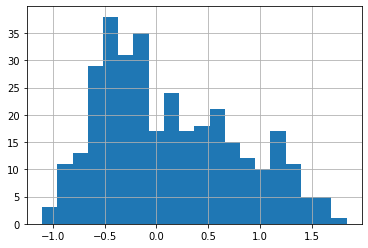

In [50]:
scaled.hist(bins=20)

### sklearn variant

```python
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
```
Check out [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html), [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) and [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html) for examples.

### General approach when using sklearn for **feature engineering**  

0. Split the data (X and y) into train and test portions.<br><br>  

1. instanciate e.g. a scaler: `scaler = MinMaxScaler()`<br><br>  

2. fit on the *train* data, e.g. `scaler.fit(X_train)` (e.g. for range calculation)  
 **Don't fit on the test data.** The *test* data is only transformed (see below) based on the fitted *train* data.<br><br>  

3. transform (e.g. scale, in general: engineer) train **and** test data:  
 `X_test_feature_engineered = scaler.transform(X_train)`  
 `...`  
 `X_test_feature_engineered = scaler.transform(X_test)` 

Realize the parallelism to ML with sklearn:  

| |step| Machine Learning | Feature Engineering |
|-| - | - | - |
|0.| split data | &rightarrow; | train_test_split(X,y) |
|1.| instanciate | model = LogisticRegression() | scaler = MinMaxScaler() |
|2.| fit to the data | model.fit(X_train, y_train) | scaler.fit(X_train) |
|3.| usage (e.g.) | model.predict(X_test) | scaler.transform(X_train)<br>scaler.transform(X_test) |

hint: When you see `.fit_transform(X)`: This fits and transforms in one go (only sensible for X_train).

## Summary

- Motivation why to engineer features
- Estimated time consumption (invest here saves time later)
- Imputation (handel missing values)  `df.fillna()`  
- One-hot-encoding (for case discrimination)  `pd.get_dummies()`
- Binning (grouping)  `pd.cut()`, `pd.qcut`
- Scaling (for getting similar ranges among different features)  *`manually`* or better: use `sklearn`
- pointer to sklearn which can handle all this as well

## Broad indications for Titanic project

Read data in  
EDA (like last week, mainly statistic/visualization).  
Split to train and test (here or before EDA!)  
Fill (or drop) NAs.  
Drop or one-hot-encode categorical columns.  
Drop unnecessary columns.  
Feature engineering (binning, scaling, ... as seen today).  
Create baseline model (dummy classifier).   
    - model.fit(x_train,y_train)  
    - model.predict(x_train)  
    - model.predict(x_test)  
    - model.score(x_train, y_train)  
    - model.score(x_test, y_test)  
Create proper model (logistic regression, ...).  
    with same modelling steps.  
Evaluate the model (confusion matrix, train-test score comparison).   